<a href="https://colab.research.google.com/github/thiskosy/credit-risk-prediction/blob/main/Credit_Risk_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('Libraries loaded successfully')

Libraries loaded successfully


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving credit_risk_dataset.csv to credit_risk_dataset (1).csv


In [ ]:
df = pd.read_csv('credit_risk_dataset.csv')

print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nFirst 5 rows:')
df.head()

Shape: (32581, 12)

Columns: ['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']

First 5 rows:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [ ]:
print('Data Types:')
print(df.dtypes)
print('\nMissing Values:')
print(df.isnull().sum())
print('\nMissing Percentage:')
print((df.isnull().sum() / len(df) * 100).round(2))

Data Types:
person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object

Missing Values:
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

Missing Percentage:
person_age                    0.00
person_incom

In [ ]:
df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace=True)
df['loan_int_rate'].fillna(df['loan_int_rate'].median(), inplace=True)

print('Missing values after cleaning:')
print(df.isnull().sum())
print('\nDataset ready for analysis!')

Missing values after cleaning:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

Dataset ready for analysis!


/tmp/ipykernel_47392/2841585168.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace=True)
/tmp/ipykernel_47392/2841585168.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].me

Loan Status Distribution:
Paid Back (0): 25,473 customers (78.2%)
Defaulted (1): 7,108 customers (21.8%)


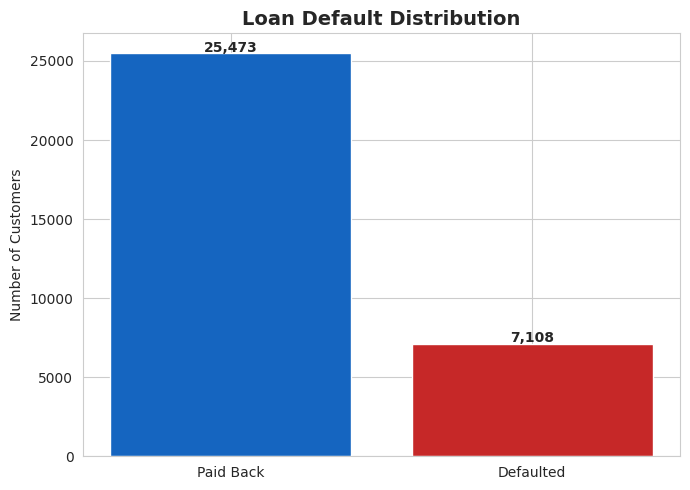

In [ ]:

default_counts = df['loan_status'].value_counts()
default_pct = df['loan_status'].value_counts(normalize=True) * 100

print('Loan Status Distribution:')
print(f'Paid Back (0): {default_counts[0]:,} customers ({default_pct[0]:.1f}%)')
print(f'Defaulted (1): {default_counts[1]:,} customers ({default_pct[1]:.1f}%)')

plt.figure(figsize=(7, 5))
bars = plt.bar(['Paid Back', 'Defaulted'],
               [default_counts[0], default_counts[1]],
               color=['#1565C0', '#C62828'])
plt.title('Loan Default Distribution', fontsize=14, fontweight='bold')
plt.ylabel('Number of Customers')
for bar, val in zip(bars, [default_counts[0], default_counts[1]]):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 100,
             f'{val:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

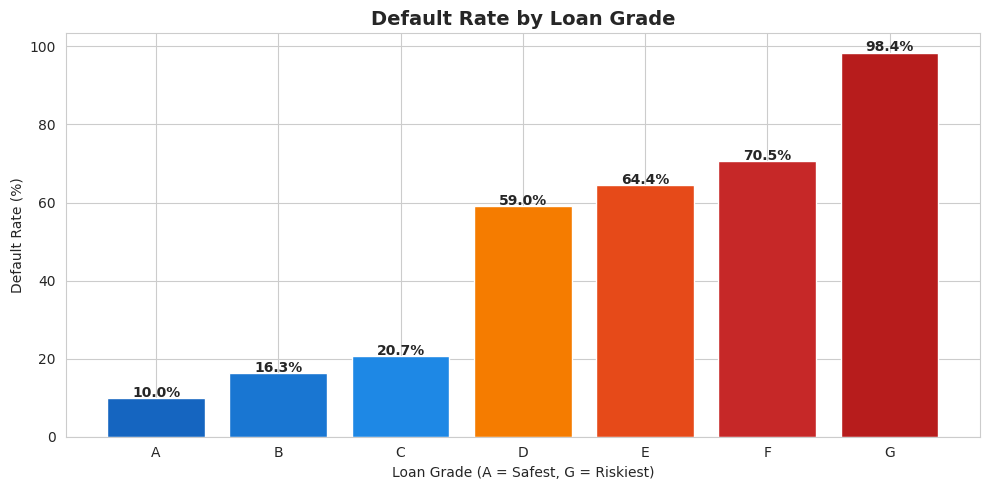

In [ ]:
# Default rate by loan grade
grade_default = df.groupby('loan_grade')['loan_status'].mean() * 100

plt.figure(figsize=(10, 5))
bars = plt.bar(grade_default.index, grade_default.values,
               color=['#1565C0','#1976D2','#1E88E5','#F57C00','#E64A19','#C62828','#B71C1C'])
plt.title('Default Rate by Loan Grade', fontsize=14, fontweight='bold')
plt.xlabel('Loan Grade (A = Safest, G = Riskiest)')
plt.ylabel('Default Rate (%)')
for bar, val in zip(bars, grade_default.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

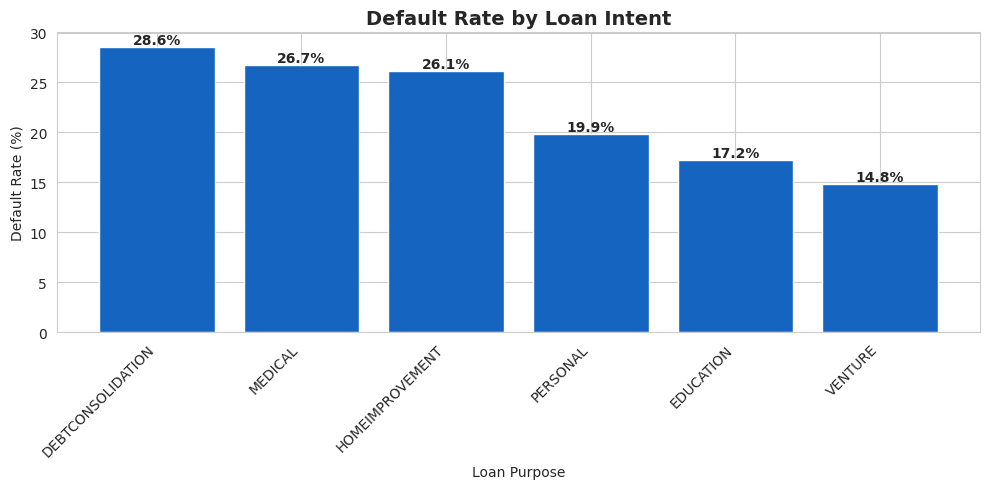

In [ ]:
# Default rate by loan intent
intent_default = df.groupby('loan_intent')['loan_status'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10, 5))
bars = plt.bar(intent_default.index, intent_default.values, color='#1565C0')
plt.title('Default Rate by Loan Intent', fontsize=14, fontweight='bold')
plt.xlabel('Loan Purpose')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=45, ha='right')
for bar, val in zip(bars, intent_default.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


/tmp/ipykernel_47392/1773346160.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_default = df.groupby('income_segment')['loan_status'].mean() * 100


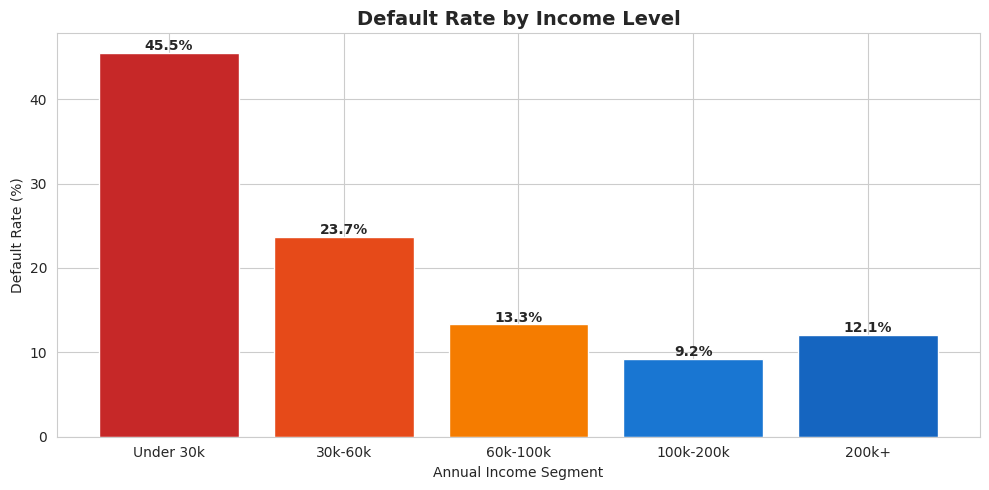

In [ ]:
# Create income segments
df['income_segment'] = pd.cut(
    df['person_income'],
    bins=[0, 30000, 60000, 100000, 200000, df['person_income'].max()],
    labels=['Under 30k', '30k-60k', '60k-100k', '100k-200k', '200k+']
)

# Default rate by income segment
income_default = df.groupby('income_segment')['loan_status'].mean() * 100

plt.figure(figsize=(10, 5))
bars = plt.bar(income_default.index, income_default.values,
               color=['#C62828','#E64A19','#F57C00','#1976D2','#1565C0'])
plt.title('Default Rate by Income Level', fontsize=14, fontweight='bold')
plt.xlabel('Annual Income Segment')
plt.ylabel('Default Rate (%)')
for bar, val in zip(bars, income_default.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

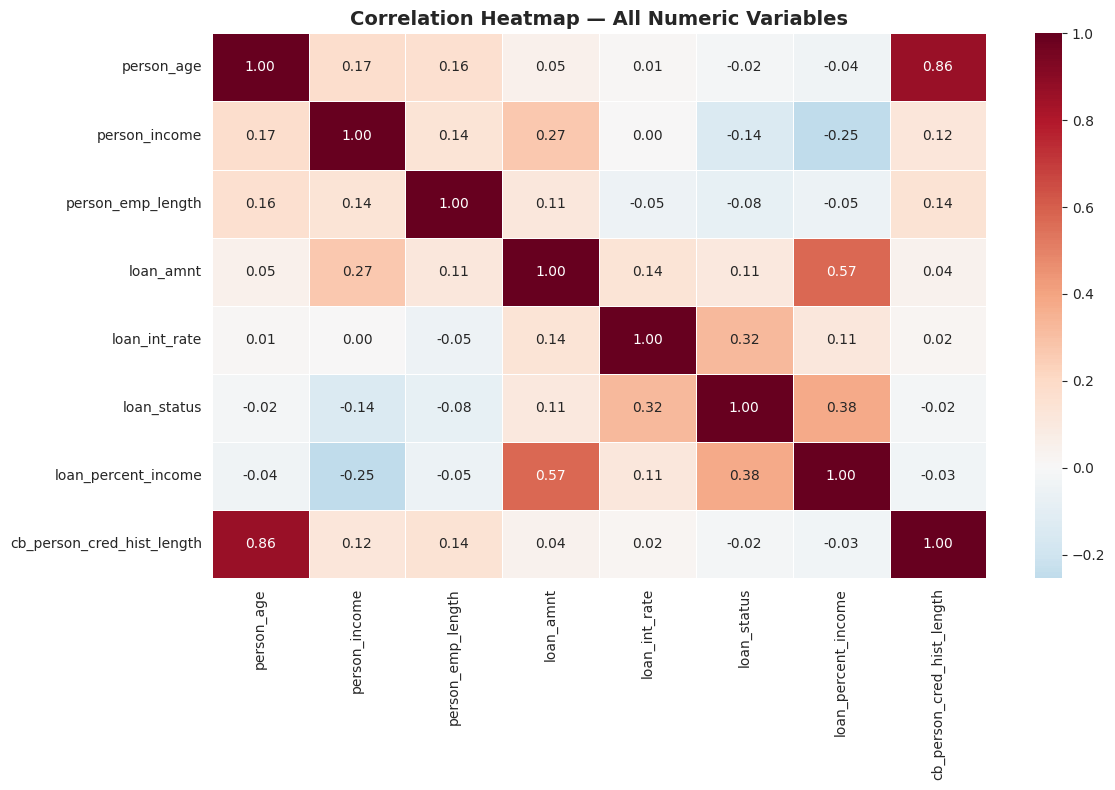

In [ ]:
# Select only numeric columns
numeric_cols = df.select_dtypes(include=[np.number])

# Calculate correlation
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            linewidths=0.5)
plt.title('Correlation Heatmap — All Numeric Variables',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [ ]:
# Prepare features for logistic regression
features = ['person_age', 'person_income', 'person_emp_length',
            'loan_amnt', 'loan_int_rate', 'loan_percent_income',
            'cb_person_cred_hist_length', 'loan_grade',
            'person_home_ownership', 'loan_intent',
            'cb_person_default_on_file']

df_model = df[features + ['loan_status']].copy()

# One-hot encode categorical variables
df_encoded = pd.get_dummies(df_model,
                             columns=['loan_grade', 'person_home_ownership',
                                      'loan_intent', 'cb_person_default_on_file'],
                             drop_first=True)

# Define X and y
X = df_encoded.drop('loan_status', axis=1)
y = df_encoded['loan_status']

# Train test split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training set: {X_train.shape[0]:,} customers')
print(f'Test set: {X_test.shape[0]:,} customers')
print(f'Features used: {X.shape[1]}')

Training set: 26,064 customers
Test set: 6,517 customers
Features used: 22


In [ ]:
# Train the logistic regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print('Model trained successfully!')
print(f'Training samples: {X_train.shape[0]:,}')
print(f'Test samples: {X_test.shape[0]:,}')

Model trained successfully!
Training samples: 26,064
Test samples: 6,517


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# Evaluate model performance
print('='*50)
print('MODEL PERFORMANCE REPORT')
print('='*50)
print()
print(classification_report(y_test, y_pred,
      target_names=['Paid Back', 'Defaulted']))
print(f'ROC-AUC Score: {roc_auc_score(y_test, y_prob):.3f}')

MODEL PERFORMANCE REPORT

              precision    recall  f1-score   support

   Paid Back       0.85      0.96      0.90      5072
   Defaulted       0.75      0.42      0.54      1445

    accuracy                           0.84      6517
   macro avg       0.80      0.69      0.72      6517
weighted avg       0.83      0.84      0.82      6517

ROC-AUC Score: 0.853


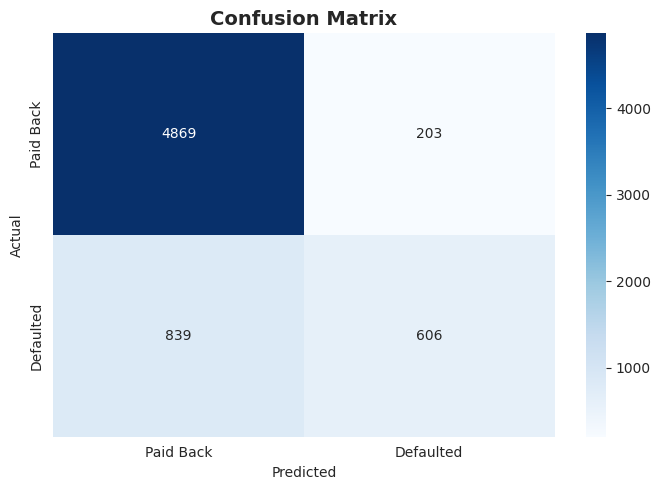

True Negatives  (Predicted Paid Back, Actually Paid Back): 4,869
False Positives (Predicted Default, Actually Paid Back):   203
False Negatives (Predicted Paid Back, Actually Defaulted): 839
True Positives  (Predicted Default, Actually Defaulted):   606

Missed Defaults (False Negatives): 839 customers
Cost to bank if avg loan is $10,000: $8,390,000


In [ ]:
# Confusion matrix visualization
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Paid Back', 'Defaulted'],
            yticklabels=['Paid Back', 'Defaulted'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Break it down
tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (Predicted Paid Back, Actually Paid Back): {tn:,}')
print(f'False Positives (Predicted Default, Actually Paid Back):   {fp:,}')
print(f'False Negatives (Predicted Paid Back, Actually Defaulted): {fn:,}')
print(f'True Positives  (Predicted Default, Actually Defaulted):   {tp:,}')
print(f'\nMissed Defaults (False Negatives): {fn:,} customers')
print(f'Cost to bank if avg loan is $10,000: ${fn * 10000:,}')

ADJUSTED THRESHOLD (30%) PERFORMANCE

              precision    recall  f1-score   support

   Paid Back       0.91      0.88      0.89      5072
   Defaulted       0.62      0.69      0.65      1445

    accuracy                           0.84      6517
   macro avg       0.77      0.79      0.77      6517
weighted avg       0.85      0.84      0.84      6517



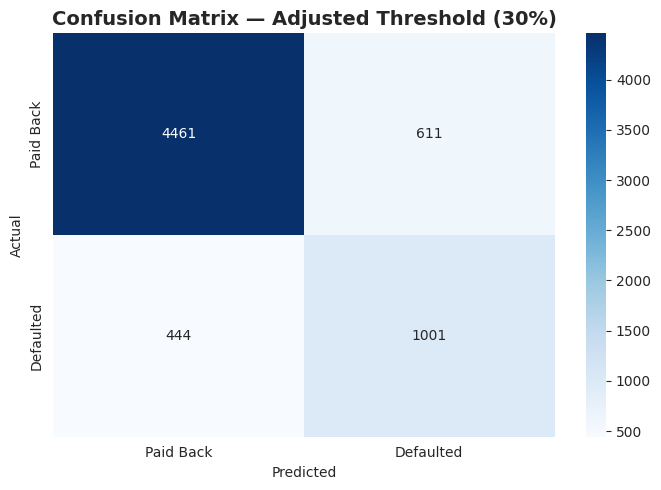

Missed Defaults: 444 customers
Cost to bank: $4,440,000
Improvement: 395 fewer missed defaults
Money saved vs original: $3,950,000


In [ ]:
# Adjust threshold from 50% to 30%
y_pred_adjusted = (y_prob >= 0.30).astype(int)

print('='*50)
print('ADJUSTED THRESHOLD (30%) PERFORMANCE')
print('='*50)
print()
print(classification_report(y_test, y_pred_adjusted,
      target_names=['Paid Back', 'Defaulted']))

# New confusion matrix
cm_adjusted = confusion_matrix(y_test, y_pred_adjusted)
tn, fp, fn, tp = cm_adjusted.ravel()

plt.figure(figsize=(7, 5))
sns.heatmap(cm_adjusted, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Paid Back', 'Defaulted'],
            yticklabels=['Paid Back', 'Defaulted'])
plt.title('Confusion Matrix — Adjusted Threshold (30%)',
          fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print(f'Missed Defaults: {fn:,} customers')
print(f'Cost to bank: ${fn * 10000:,}')
print(f'Improvement: {839 - fn:,} fewer missed defaults')
print(f'Money saved vs original: ${(839-fn) * 10000:,}')

In [ ]:
# Score every customer with default probability
df_test = X_test.copy()
df_test['default_probability'] = (y_prob * 100).round(1)
df_test['actual_outcome'] = y_test.values

# Assign risk tiers
def assign_risk(prob):
    if prob >= 60:
        return 'HIGH RISK — Reject'
    elif prob >= 30:
        return 'MEDIUM RISK — Review'
    else:
        return 'LOW RISK — Approve'

df_test['risk_tier'] = df_test['default_probability'].apply(assign_risk)

# Summary
print('Risk Tier Distribution:')
print(df_test['risk_tier'].value_counts())
print()

# Sample table
sample = df_test[['default_probability', 'risk_tier', 'actual_outcome']].sample(10, random_state=42)
sample = sample.sort_values('default_probability', ascending=False)
print('Sample Customer Scoring Table:')
print(sample.to_string())

Risk Tier Distribution:
risk_tier
LOW RISK — Approve      4901
MEDIUM RISK — Review    1002
HIGH RISK — Reject       614
Name: count, dtype: int64

Sample Customer Scoring Table:
       default_probability           risk_tier  actual_outcome
20835                 84.5  HIGH RISK — Reject               1
26024                 70.2  HIGH RISK — Reject               1
5665                  28.5  LOW RISK — Approve               0
6126                  16.7  LOW RISK — Approve               0
17306                  8.8  LOW RISK — Approve               0
29681                  6.3  LOW RISK — Approve               0
25528                  5.4  LOW RISK — Approve               0
32281                  3.8  LOW RISK — Approve               0
12036                  3.6  LOW RISK — Approve               1
27229                  1.5  LOW RISK — Approve               1


In [ ]:
print("""
================================================
CREDIT RISK MODEL — BUSINESS RECOMMENDATIONS
================================================

MODEL PERFORMANCE:
  Accuracy:     84%
  ROC-AUC:      0.853
  Threshold:    30% (optimized)

RISK TIER SUMMARY:
  LOW RISK   — Auto Approve:  4,901 customers (75%)
  MEDIUM RISK — Manual Review: 1,002 customers (15%)
  HIGH RISK  — Auto Reject:     614 customers  (9%)

KEY FINDINGS:
  1. Loan grade is the strongest categorical predictor
     Grade A defaults at 10% vs Grade G at 98%

  2. Debt consolidation loans carry highest default risk (28.6%)
     Venture loans carry lowest default risk (14.8%)

  3. Low income borrowers (under 30k) default at 45.5%
     Nearly 5x the rate of 100k-200k earners

  4. loan_percent_income (0.38) and loan_int_rate (0.32)
     are the strongest numeric predictors of default

RECOMMENDATIONS:
  1. Apply stricter underwriting for Grade D and below
  2. Require additional collateral for debt consolidation loans
  3. Cap loan_percent_income at 35% for auto-approval
  4. Review all medium risk customers manually before approval
  5. Retrain model quarterly as new loan data accumulates

NEXT STEPS TO IMPROVE MODEL:
  1. Try XGBoost — likely to achieve ROC-AUC above 0.90
  2. Apply SMOTE to address class imbalance
  3. Add macroeconomic features — unemployment rate, GDP
  4. Build a real time scoring API for live applications
================================================
""")


CREDIT RISK MODEL — BUSINESS RECOMMENDATIONS

MODEL PERFORMANCE:
  Accuracy:     84%
  ROC-AUC:      0.853
  Threshold:    30% (optimized)

RISK TIER SUMMARY:
  LOW RISK   — Auto Approve:  4,901 customers (75%)
  MEDIUM RISK — Manual Review: 1,002 customers (15%)
  HIGH RISK  — Auto Reject:     614 customers  (9%)

KEY FINDINGS:
  1. Loan grade is the strongest categorical predictor
     Grade A defaults at 10% vs Grade G at 98%
     
  2. Debt consolidation loans carry highest default risk (28.6%)
     Venture loans carry lowest default risk (14.8%)
     
  3. Low income borrowers (under 30k) default at 45.5%
     Nearly 5x the rate of 100k-200k earners
     
  4. loan_percent_income (0.38) and loan_int_rate (0.32)
     are the strongest numeric predictors of default

RECOMMENDATIONS:
  1. Apply stricter underwriting for Grade D and below
  2. Require additional collateral for debt consolidation loans
  3. Cap loan_percent_income at 35% for auto-approval
  4. Review all medium risk c